In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Ensure NLTK datasets are downloaded
nltk.download('stopwords')
nltk.download('punkt')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to C:\Users\Mahesh
[nltk_data]     MIshra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Mahesh
[nltk_data]     MIshra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [9]:
# ---------------------------------------------------------
# Step 1: Load and Inspect Dataset
# ---------------------------------------------------------
# Load dataset
data = pd.read_csv('spam_ham_dataset.csv')

# Drop unnecessary index column if present
if 'Unnamed: 0' in data.columns:
    data.drop(columns=['Unnamed: 0'], inplace=True)

data.head()

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      5171 non-null   object
 1   text       5171 non-null   object
 2   label_num  5171 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 121.3+ KB


In [11]:
data.describe()

,label_num
count,5171.000000
mean,0.289886
std,0.453753
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [12]:
data.shape

(5171, 3)

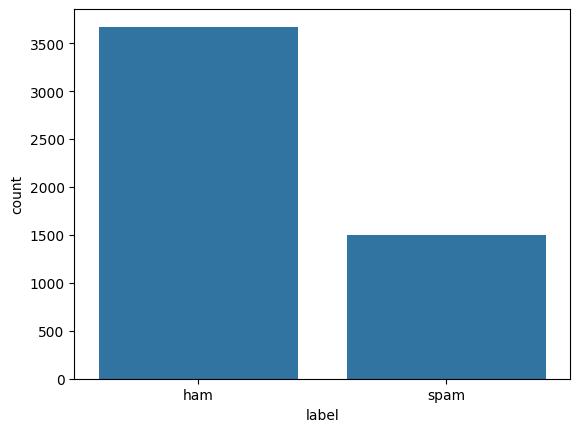

In [13]:
#label distribution to get understanding of the class distribution:
sns.countplot(x='label', data=data)
plt.show()

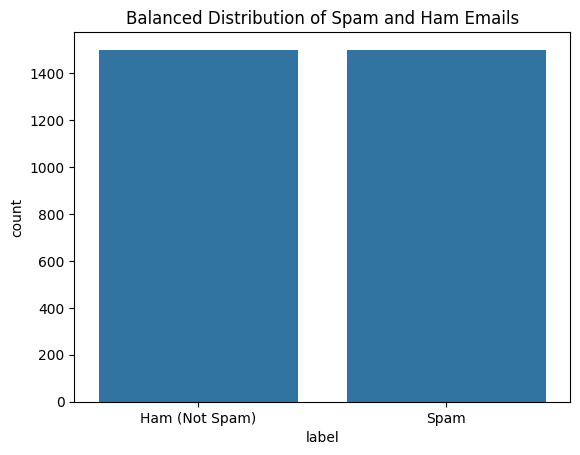

In [14]:
# ---------------------------------------------------------
# Step 2: Balance the Dataset
# ---------------------------------------------------------
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Downsample Ham emails to match Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()

In [4]:
# ---------------------------------------------------------
# Step 3: Text Preprocessing
# ---------------------------------------------------------
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove 'Subject:' header if present
    text = re.sub(r'^Subject:', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove numbers and line breaks
    text = re.sub(r'\r\n|\n', ' ', text)
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove stopwords
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]
    return ' '.join(cleaned_words)

balanced_data['clean_text'] = balanced_data['text'].apply(clean_text)

In [5]:
# ---------------------------------------------------------
# Step 4: Tokenization & Sequence Padding
# ---------------------------------------------------------
MAX_WORDS = 10000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(balanced_data['clean_text'])

sequences = tokenizer.texts_to_sequences(balanced_data['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = balanced_data['label_num'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# ---------------------------------------------------------
# Step 5: Model Building
# ---------------------------------------------------------
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-5)

In [7]:
# ---------------------------------------------------------
# Step 6: Train the Model
# ---------------------------------------------------------
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.8113 - loss: 0.4476 - val_accuracy: 0.9688 - val_loss: 0.1134 - learning_rate: 0.0010
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9828 - loss: 0.0644 - val_accuracy: 0.9833 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9953 - loss: 0.0221 - val_accuracy: 0.9875 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9937 - loss: 0.0199 - val_accuracy: 0.9292 - val_loss: 0.1696 - learning_rate: 0.0010
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9953 - loss: 0.0187 - val_accuracy: 0.9729 - val_loss: 0.0733 - learning_rate: 0.0010
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9990 - loss: 0.0060 - val_accuracy: 0.9833 - val_loss: 0.0719 - learning_rate: 2.0000e-04



Test Accuracy: 98.33%
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       300
           1       0.98      0.99      0.98       300

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



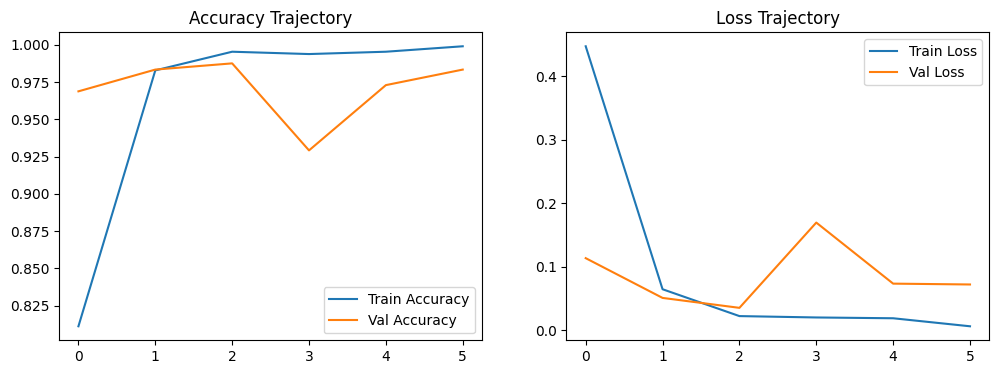

In [8]:
# ---------------------------------------------------------
# Step 7: Model Evaluation
# ---------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot training history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Accuracy Trajectory')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Loss Trajectory')
ax[1].legend()

plt.show()